# 06 — Premium and Collectible Asset Detection

## Plate Value Intelligence

This notebook develops a decision layer for identifying premium, collectible, and specialist-review licence-plate assets.

### Objectives

- Separate observed premium value from structural collectibility
- Define transparent premium and collectible signals
- Evaluate premium-asset identification performance
- Create a portfolio segmentation framework
- Route uncertain or exceptional assets for specialist review
- Prepare outputs for pricing and auction-strategy simulation

### Analytical principle

A high sale price and a collectible asset are related but not identical concepts.

Premium status is based on observed market value, while collectibility is assessed using structural scarcity, memorability, rarity, and semantic potential.

In [89]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

In [90]:
PROJECT_ROOT = Path.cwd()

FEATURE_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "plate_features_2025.csv"
)

FINAL_PREDICTIONS_FILE = (
    PROJECT_ROOT
    / "reports"
    / "final_valuation_test_predictions_2025.csv"
)

REPORTS_DIR = PROJECT_ROOT / "reports"

print(f"Feature file exists: {FEATURE_FILE.exists()}")
print(
    f"Final predictions file exists: "
    f"{FINAL_PREDICTIONS_FILE.exists()}"
)

Feature file exists: True
Final predictions file exists: True


In [91]:
df_features = pd.read_csv(FEATURE_FILE)

validation_group_map = {
    "B270": "train",
    "B271": "train",
    "B272": "train",
    "B273": "train",
    "B274": "train",
    "B275": "train",
    "B276": "train",
    "B277": "validation",
    "B278": "test",
}

df_features["model_split"] = (
    df_features["event_code"]
    .map(validation_group_map)
)

missing_split_events = sorted(
    df_features.loc[
        df_features["model_split"].isna(),
        "event_code",
    ]
    .dropna()
    .unique()
)

if missing_split_events:
    raise ValueError(
        "Missing model_split mapping for events: "
        f"{missing_split_events}"
    )

df_test_predictions = pd.read_csv(
    FINAL_PREDICTIONS_FILE
)

print(f"Feature rows: {len(df_features):,}")
print(
    f"Final test prediction rows: "
    f"{len(df_test_predictions):,}"
)
print(
    "Model splits: "
    f"{sorted(df_features['model_split'].unique())}"
)

Feature rows: 17,782
Final test prediction rows: 1,981
Model splits: ['test', 'train', 'validation']


In [92]:
required_feature_columns = [
    "event_code",
    "lot_number",
    "plate_raw",
    "plate_clean",
    "hammer_price_gbp",
    "plate_length",
    "numeric_value",
    "low_number_score",
    "has_repeated_digit",
    "has_repeated_letter",
    "all_digits_same",
    "all_letters_same",
    "has_sequential_pattern",
    "is_short_plate_len_3_or_less",
    "is_short_plate_len_4_or_less",
    "is_round_number",
    "is_milestone_number",
    "plate_pattern",
    "plate_format_group",
    "is_premium_top_10pct",
    "is_premium_top_5pct",
    "is_premium_top_1pct",
    "model_split",
]

missing_columns = [
    column
    for column in required_feature_columns
    if column not in df_features.columns
]

assert not missing_columns, (
    f"Missing required columns: {missing_columns}"
)

print("Premium and collectibility inputs are available.")

Premium and collectibility inputs are available.


## 1. Premium Value vs Collectibility

Two related but distinct concepts are used:

### Premium value

A market-observed concept based on hammer-price position within the auction distribution.

Examples:

- Top 10%: premium
- Top 5%: high premium
- Top 1%: trophy-value asset

### Collectibility

A structural and commercial concept based on characteristics such as:

- brevity,
- low or distinctive numbers,
- repeated or symmetrical patterns,
- memorability,
- rare formats,
- and potential semantic meaning.

A plate may be collectible even when its current observed price is not yet exceptionally high. Likewise, a high-priced plate may not possess strong structural collectibility.

In [93]:
df_assets = df_features.copy()

df_assets["brevity_points"] = np.select(
    [
        df_assets["plate_length"].le(3),
        df_assets["plate_length"].eq(4),
        df_assets["plate_length"].eq(5),
    ],
    [
        30,
        22,
        10,
    ],
    default=0,
)

In [94]:
df_assets["numeric_rarity_points"] = np.select(
    [
        df_assets["numeric_value"].between(
            0,
            9,
            inclusive="both",
        ),
        df_assets["numeric_value"].between(
            10,
            99,
            inclusive="both",
        ),
        df_assets["numeric_value"].between(
            100,
            999,
            inclusive="both",
        ),
    ],
    [
        25,
        15,
        5,
    ],
    default=0,
)

In [95]:
df_assets["memorability_points"] = (
    df_assets["all_digits_same"] * 10
    + df_assets["all_letters_same"] * 8
    + df_assets["has_sequential_pattern"] * 8
    + df_assets["is_round_number"] * 5
    + df_assets["is_milestone_number"] * 5
)

In [96]:
df_assets["structure_points"] = (
    df_assets["is_short_plate_len_4_or_less"] * 10
    + df_assets["has_repeated_digit"] * 3
    + df_assets["has_repeated_letter"] * 2
)

In [97]:
df_assets["collectibility_score_raw"] = (
    df_assets["brevity_points"]
    + df_assets["numeric_rarity_points"]
    + df_assets["memorability_points"]
    + df_assets["structure_points"]
)

df_assets["collectibility_score"] = (
    df_assets["collectibility_score_raw"]
    .clip(lower=0, upper=100)
)

In [98]:
collectibility_summary = (
    df_assets["collectibility_score"]
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .to_frame(
        name="collectibility_score"
    )
)

collectibility_summary

,collectibility_score
count,"17,782.00"
mean,21.98
std,14.40
min,0.00
50%,17.00
75%,33.00
90%,42.00
95%,53.00
99%,62.00
max,70.00


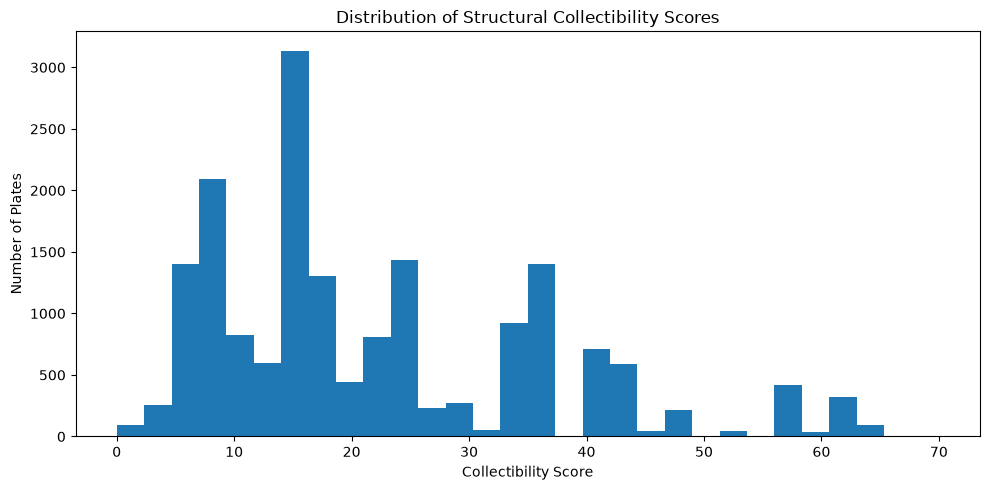

In [99]:
ax = df_assets[
    "collectibility_score"
].plot(
    kind="hist",
    bins=30,
    figsize=(10, 5),
)

ax.set_title(
    "Distribution of Structural Collectibility Scores"
)
ax.set_xlabel("Collectibility Score")
ax.set_ylabel("Number of Plates")

plt.tight_layout()
plt.show(block=False)
plt.close(ax.get_figure())

## 2. Collectibility Segmentation

The transparent collectibility score is converted into stakeholder-friendly portfolio segments. These thresholds are provisional and will be validated against observed premium outcomes.

In [100]:
df_assets["collectibility_segment"] = pd.cut(
    df_assets["collectibility_score"],
    bins=[
        -np.inf,
        14,
        29,
        44,
        59,
        np.inf,
    ],
    labels=[
        "Standard",
        "Distinctive",
        "Collectible",
        "High Collectible",
        "Trophy Candidate",
    ],
)

In [101]:
collectibility_segment_summary = (
    df_assets.groupby(
        "collectibility_segment",
        observed=True,
    )
    .agg(
        plate_count=("plate_clean", "size"),
        median_price_gbp=("hammer_price_gbp", "median"),
        mean_price_gbp=("hammer_price_gbp", "mean"),
        percentile_90_price_gbp=(
            "hammer_price_gbp",
            lambda values: values.quantile(0.90),
        ),
        premium_top_10_rate=(
            "is_premium_top_10pct",
            "mean",
        ),
        premium_top_5_rate=(
            "is_premium_top_5pct",
            "mean",
        ),
        trophy_top_1_rate=(
            "is_premium_top_1pct",
            "mean",
        ),
    )
    .reset_index()
)

for column in [
    "premium_top_10_rate",
    "premium_top_5_rate",
    "trophy_top_1_rate",
]:
    collectibility_segment_summary[
        f"{column}_pct"
    ] = (
        collectibility_segment_summary[column]
        * 100
    )

collectibility_segment_summary

,collectibility_segment,plate_count,median_price_gbp,mean_price_gbp,percentile_90_price_gbp,premium_top_10_rate,premium_top_5_rate,trophy_top_1_rate,premium_top_10_rate_pct,premium_top_5_rate_pct,trophy_top_1_rate_pct
0,Standard,5262,"1,010.00","1,595.56","3,510.00",0.03,0.01,0.00,2.81,1.25,0.13
1,Distinctive,7375,"1,360.00","2,171.56","5,000.00",0.07,0.03,0.00,7.05,3.01,0.42
2,Collectible,3942,"1,780.00","2,785.52","5,910.00",0.11,0.06,0.02,10.55,5.68,1.55
3,High Collectible,780,"6,010.00","6,956.51","10,298.00",0.56,0.25,0.05,56.41,25.13,4.62
4,Trophy Candidate,423,"6,810.00","8,418.46","14,068.00",0.61,0.43,0.10,60.52,43.03,10.40


In [102]:
collectibility_price_relationship = (
    df_assets[
        [
            "collectibility_score",
            "hammer_price_gbp",
            "log_hammer_price",
        ]
    ]
    .corr(
        method="spearman"
    )
)

collectibility_price_relationship

,collectibility_score,hammer_price_gbp,log_hammer_price
collectibility_score,1.00,0.38,0.38
hammer_price_gbp,0.38,1.00,1.00
log_hammer_price,0.38,1.00,1.00


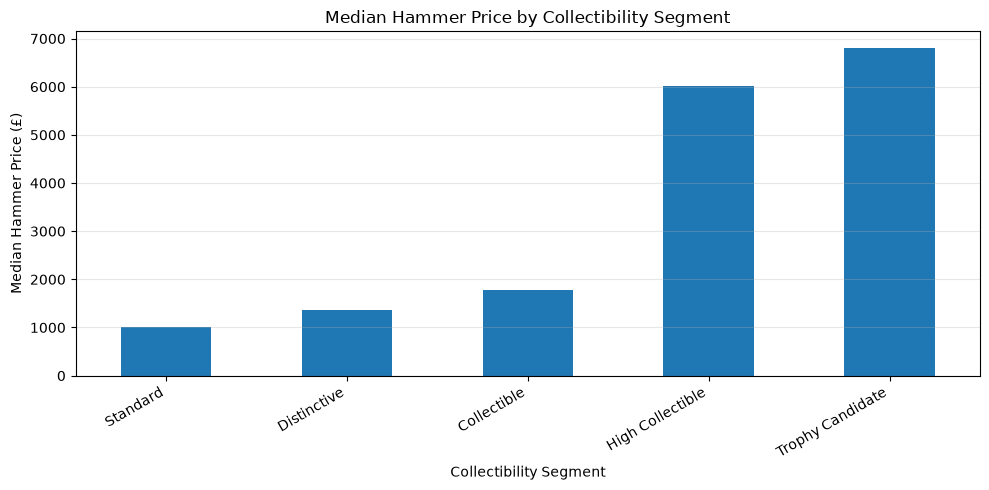

In [103]:
plot_data = (
    collectibility_segment_summary
    .set_index(
        "collectibility_segment"
    )["median_price_gbp"]
)

ax = plot_data.plot(
    kind="bar",
    figsize=(10, 5),
)

ax.set_title(
    "Median Hammer Price by Collectibility Segment"
)
ax.set_xlabel("Collectibility Segment")
ax.set_ylabel("Median Hammer Price (£)")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show(block=False)
plt.close(ax.get_figure())

## 3. Premium–Collectibility Matrix

Observed market value and structural collectibility are combined to distinguish current premium assets from potentially under-recognised collectible assets.

In [104]:
df_assets["is_structurally_collectible"] = (
    df_assets["collectibility_score"]
    .ge(45)
    .astype(int)
)

df_assets["is_observed_premium"] = (
    df_assets["is_premium_top_10pct"]
    .astype(int)
)

In [105]:
df_assets["premium_collectibility_group"] = np.select(
    [
        (
            df_assets["is_observed_premium"].eq(1)
            & df_assets["is_structurally_collectible"].eq(1)
        ),
        (
            df_assets["is_observed_premium"].eq(1)
            & df_assets["is_structurally_collectible"].eq(0)
        ),
        (
            df_assets["is_observed_premium"].eq(0)
            & df_assets["is_structurally_collectible"].eq(1)
        ),
    ],
    [
        "Premium + Collectible",
        "Premium Value Only",
        "Collectible Potential",
    ],
    default="Standard Portfolio",
)

In [106]:
premium_collectibility_summary = (
    df_assets.groupby(
        "premium_collectibility_group"
    )
    .agg(
        plate_count=("plate_clean", "size"),
        median_price_gbp=("hammer_price_gbp", "median"),
        mean_price_gbp=("hammer_price_gbp", "mean"),
        median_collectibility_score=(
            "collectibility_score",
            "median",
        ),
    )
    .reset_index()
    .sort_values(
        "median_price_gbp",
        ascending=False,
    )
)

premium_collectibility_summary

,premium_collectibility_group,plate_count,median_price_gbp,mean_price_gbp,median_collectibility_score
1,Premium + Collectible,696,"8,010.00","9,929.20",57.00
2,Premium Value Only,1084,"7,570.00","9,160.54",25.00
0,Collectible Potential,507,"4,010.00","4,095.40",57.00
3,Standard Portfolio,15495,"1,210.00","1,643.21",15.00


In [107]:
collectible_potential_examples = (
    df_assets.loc[
        df_assets[
            "premium_collectibility_group"
        ].eq("Collectible Potential"),
        [
            "event_code",
            "lot_number",
            "plate_raw",
            "hammer_price_gbp",
            "collectibility_score",
            "collectibility_segment",
            "plate_length",
            "numeric_value",
            "all_digits_same",
            "has_sequential_pattern",
            "is_round_number",
            "is_milestone_number",
        ],
    ]
    .sort_values(
        [
            "collectibility_score",
            "hammer_price_gbp",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(30)
)

collectible_potential_examples

,event_code,lot_number,plate_raw,hammer_price_gbp,collectibility_score,collectibility_segment,plate_length,numeric_value,all_digits_same,has_sequential_pattern,is_round_number,is_milestone_number
312,B270,316,9 CBA,"5,010.00",70,Trophy Candidate,4,9,0,1,0,1
7738,B273,1836,7 UTS,"4,510.00",70,Trophy Candidate,4,7,0,1,0,1
5273,B272,1349,55 OV,"5,460.00",65,Trophy Candidate,4,55,1,0,0,1
8397,B274,503,33 DU,"5,310.00",65,Trophy Candidate,4,33,1,0,0,1
4631,B272,700,44 GY,"5,260.00",65,Trophy Candidate,4,44,1,0,0,1
3848,B271,1912,9 WRW,"5,260.00",64,Trophy Candidate,4,9,0,0,0,1
1533,B270,1560,9 RRY,"5,130.00",64,Trophy Candidate,4,9,0,0,0,1
6231,B273,318,9 CHH,"5,120.00",64,Trophy Candidate,4,9,0,0,0,1
17656,B278,1873,7 VOV,"5,080.00",64,Trophy Candidate,4,7,0,0,0,1
4568,B272,635,7 GGM,"5,050.00",64,Trophy Candidate,4,7,0,0,0,1


In [108]:
trophy_candidates = (
    df_assets.loc[
        (
            df_assets[
                "collectibility_segment"
            ].eq("Trophy Candidate")
        )
        | (
            df_assets[
                "is_premium_top_1pct"
            ].eq(1)
        ),
        [
            "event_code",
            "lot_number",
            "plate_raw",
            "hammer_price_gbp",
            "collectibility_score",
            "collectibility_segment",
            "is_premium_top_10pct",
            "is_premium_top_5pct",
            "is_premium_top_1pct",
            "plate_length",
            "numeric_value",
            "plate_pattern",
            "plate_format_group",
        ],
    ]
    .sort_values(
        [
            "is_premium_top_1pct",
            "collectibility_score",
            "hammer_price_gbp",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
)

print(
    f"Trophy candidate rows: "
    f"{len(trophy_candidates):,}"
)

trophy_candidates.head(30)

Trophy candidate rows: 558


,event_code,lot_number,plate_raw,hammer_price_gbp,collectibility_score,collectibility_segment,is_premium_top_10pct,is_premium_top_5pct,is_premium_top_1pct,plate_length,numeric_value,plate_pattern,plate_format_group
8539,B274,646,8 FU,"90,000.00",70,Trophy Candidate,1,1,1,3,8,DLL,digits_then_letters
9833,B274,1951,9 XN,"45,010.00",70,Trophy Candidate,1,1,1,3,9,DLL,digits_then_letters
6546,B273,635,7 FU,"42,510.00",70,Trophy Candidate,1,1,1,3,7,DLL,digits_then_letters
2597,B271,643,3 FU,"70,000.00",65,Trophy Candidate,1,1,1,3,3,DLL,digits_then_letters
5266,B272,1342,1 ORO,"26,260.00",64,Trophy Candidate,1,1,1,4,1,DLLL,digits_then_letters
17000,B278,1209,8 MMR,"20,530.00",64,Trophy Candidate,1,1,1,4,8,DLLL,digits_then_letters
5692,B272,1773,1 TLT,"18,140.00",64,Trophy Candidate,1,1,1,4,1,DLLL,digits_then_letters
6870,B273,962,7 KKS,"15,010.00",64,Trophy Candidate,1,1,1,4,7,DLLL,digits_then_letters
11684,B275,1830,1 TXX,"14,510.00",64,Trophy Candidate,1,1,1,4,1,DLLL,digits_then_letters
5826,B272,1908,7 WOW,"14,080.00",64,Trophy Candidate,1,1,1,4,7,DLLL,digits_then_letters


In [109]:
df_assets["specialist_review_required"] = np.where(
    (
        df_assets["collectibility_score"].ge(60)
    )
    | (
        df_assets["premium_collectibility_group"]
        .isin(
            [
                "Premium Value Only",
                "Collectible Potential",
            ]
        )
    ),
    1,
    0,
)

In [110]:
def assign_review_reason(row) -> str:
    reasons = []

    if row["collectibility_score"] >= 60:
        reasons.append(
            "very_high_structural_collectibility"
        )

    if (
        row["premium_collectibility_group"]
        == "Premium Value Only"
    ):
        reasons.append(
            "high_market_value_not_fully_explained"
        )

    if (
        row["premium_collectibility_group"]
        == "Collectible Potential"
    ):
        reasons.append(
            "structural_collectibility_above_observed_value"
        )

    if not reasons:
        return "standard_automated_path"

    return "|".join(reasons)


df_assets["specialist_review_reason"] = (
    df_assets.apply(
        assign_review_reason,
        axis=1,
    )
)

In [111]:
specialist_review_summary = (
    df_assets.groupby(
        [
            "specialist_review_required",
            "specialist_review_reason",
        ]
    )
    .agg(
        plate_count=("plate_clean", "size"),
        median_price_gbp=("hammer_price_gbp", "median"),
        median_collectibility_score=(
            "collectibility_score",
            "median",
        ),
    )
    .reset_index()
    .sort_values(
        "plate_count",
        ascending=False,
    )
)

specialist_review_summary

,specialist_review_required,specialist_review_reason,plate_count,median_price_gbp,median_collectibility_score
0,0,standard_automated_path,15935,"1,220.00",15.00
1,1,high_market_value_not_fully_explained,1084,"7,570.00",25.00
2,1,structural_collectibility_above_observed_value,340,"4,010.00",57.00
3,1,very_high_structural_collectibility,256,"9,005.00",62.00
4,1,very_high_structural_collectibility|structural_collectibility_above_observed_value,167,"4,000.00",62.00


## 4. Segment Lift and Validation

Collectibility segments are evaluated against the overall portfolio baseline. Lift metrics show whether each segment concentrates premium assets more effectively than the average portfolio.

In [112]:
overall_median_price = (
    df_assets["hammer_price_gbp"]
    .median()
)

overall_premium_rate = (
    df_assets["is_premium_top_10pct"]
    .mean()
)

collectibility_segment_summary[
    "median_price_lift_vs_portfolio"
] = (
    collectibility_segment_summary[
        "median_price_gbp"
    ]
    / overall_median_price
)

collectibility_segment_summary[
    "premium_rate_lift_vs_portfolio"
] = (
    collectibility_segment_summary[
        "premium_top_10_rate"
    ]
    / overall_premium_rate
)

collectibility_segment_summary[
    [
        "collectibility_segment",
        "plate_count",
        "median_price_gbp",
        "median_price_lift_vs_portfolio",
        "premium_top_10_rate_pct",
        "premium_rate_lift_vs_portfolio",
    ]
]

,collectibility_segment,plate_count,median_price_gbp,median_price_lift_vs_portfolio,premium_top_10_rate_pct,premium_rate_lift_vs_portfolio
0,Standard,5262,"1,010.00",0.67,2.81,0.28
1,Distinctive,7375,"1,360.00",0.90,7.05,0.70
2,Collectible,3942,"1,780.00",1.18,10.55,1.05
3,High Collectible,780,"6,010.00",3.98,56.41,5.64
4,Trophy Candidate,423,"6,810.00",4.51,60.52,6.05


In [113]:
segment_order = [
    "Standard",
    "Distinctive",
    "Collectible",
    "High Collectible",
    "Trophy Candidate",
]

ordered_segment_summary = (
    collectibility_segment_summary
    .set_index("collectibility_segment")
    .reindex(segment_order)
    .reset_index()
)

ordered_segment_summary[
    [
        "collectibility_segment",
        "plate_count",
        "median_price_gbp",
        "premium_top_10_rate_pct",
        "premium_top_5_rate_pct",
        "trophy_top_1_rate_pct",
    ]
]

,collectibility_segment,plate_count,median_price_gbp,premium_top_10_rate_pct,premium_top_5_rate_pct,trophy_top_1_rate_pct
0,Standard,5262,"1,010.00",2.81,1.25,0.13
1,Distinctive,7375,"1,360.00",7.05,3.01,0.42
2,Collectible,3942,"1,780.00",10.55,5.68,1.55
3,High Collectible,780,"6,010.00",56.41,25.13,4.62
4,Trophy Candidate,423,"6,810.00",60.52,43.03,10.40


In [114]:
test_asset_summary = (
    df_assets.loc[
        df_assets["model_split"].eq("test")
    ]
    .groupby(
        "collectibility_segment",
        observed=True,
    )
    .agg(
        plate_count=("plate_clean", "size"),
        median_price_gbp=("hammer_price_gbp", "median"),
        premium_top_10_rate=(
            "is_premium_top_10pct",
            "mean",
        ),
    )
    .reset_index()
)

test_asset_summary[
    "premium_top_10_rate_pct"
] = (
    test_asset_summary[
        "premium_top_10_rate"
    ]
    * 100
)

test_asset_summary

,collectibility_segment,plate_count,median_price_gbp,premium_top_10_rate,premium_top_10_rate_pct
0,Standard,548,"1,010.00",0.03,2.55
1,Distinctive,833,"1,300.00",0.08,7.80
2,Collectible,459,"1,810.00",0.11,10.68
3,High Collectible,92,"6,300.00",0.64,64.13
4,Trophy Candidate,49,"7,910.00",0.63,63.27


In [115]:
review_rate_summary = pd.DataFrame(
    {
        "portfolio_path": [
            "Automated standard path",
            "Specialist review",
        ],
        "plate_count": [
            int(
                df_assets[
                    "specialist_review_required"
                ].eq(0).sum()
            ),
            int(
                df_assets[
                    "specialist_review_required"
                ].eq(1).sum()
            ),
        ],
    }
)

review_rate_summary["portfolio_share_pct"] = (
    review_rate_summary["plate_count"]
    / len(df_assets)
    * 100
)

review_rate_summary

,portfolio_path,plate_count,portfolio_share_pct
0,Automated standard path,15935,89.61
1,Specialist review,1847,10.39


In [116]:
asset_decision_table = df_assets[
    [
        "event_code",
        "lot_number",
        "plate_raw",
        "plate_clean",
        "hammer_price_gbp",
        "collectibility_score",
        "collectibility_segment",
        "premium_collectibility_group",
        "specialist_review_required",
        "specialist_review_reason",
        "plate_length",
        "numeric_value",
        "plate_pattern",
        "plate_format_group",
        "is_premium_top_10pct",
        "is_premium_top_5pct",
        "is_premium_top_1pct",
        "model_split",
    ]
].copy()

asset_decision_table.head()

,event_code,lot_number,plate_raw,plate_clean,hammer_price_gbp,collectibility_score,collectibility_segment,premium_collectibility_group,specialist_review_required,specialist_review_reason,plate_length,numeric_value,plate_pattern,plate_format_group,is_premium_top_10pct,is_premium_top_5pct,is_premium_top_1pct,model_split
0,B270,1,1984 A,1984A,"6,510.00",10,Standard,Premium Value Only,1,high_market_value_not_fully_explained,5,1984,DDDDL,digits_then_letters,1,0,0,train
1,B270,2,7777 AA,7777AA,"5,560.00",28,Distinctive,Standard Portfolio,0,standard_automated_path,6,7777,DDDDLL,digits_then_letters,0,0,0,train
2,B270,3,AAD 8L,AAD8L,"3,710.00",42,Collectible,Standard Portfolio,0,standard_automated_path,5,8,LLLDL,letters_digits_letters,0,0,0,train
3,B270,4,A881 AKA,A881AKA,480.00,10,Standard,Standard Portfolio,0,standard_automated_path,7,881,LDDDLLL,letters_digits_letters,0,0,0,train
4,B270,5,AAK 64R,AAK64R,"3,140.00",17,Distinctive,Standard Portfolio,0,standard_automated_path,6,64,LLLDDL,letters_digits_letters,0,0,0,train


In [117]:
REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

collectibility_segment_summary.to_csv(
    REPORTS_DIR
    / "collectibility_segment_summary_2025.csv",
    index=False,
)

premium_collectibility_summary.to_csv(
    REPORTS_DIR
    / "premium_collectibility_matrix_2025.csv",
    index=False,
)

collectible_potential_examples.to_csv(
    REPORTS_DIR
    / "collectible_potential_examples_2025.csv",
    index=False,
)

trophy_candidates.to_csv(
    REPORTS_DIR
    / "trophy_asset_candidates_2025.csv",
    index=False,
)

specialist_review_summary.to_csv(
    REPORTS_DIR
    / "specialist_review_summary_2025.csv",
    index=False,
)

review_rate_summary.to_csv(
    REPORTS_DIR
    / "specialist_review_rate_2025.csv",
    index=False,
)

test_asset_summary.to_csv(
    REPORTS_DIR
    / "collectibility_holdout_summary_2025.csv",
    index=False,
)

asset_decision_table.to_csv(
    REPORTS_DIR
    / "premium_collectible_asset_decisions_2025.csv",
    index=False,
)

print(
    "Premium and collectible asset reports "
    "saved successfully."
)

Premium and collectible asset reports saved successfully.


## 5. Premium and Collectible Asset Conclusion

This notebook introduced a transparent decision layer separating observed premium value from structural collectibility.

### Key findings

- Premium value and collectibility are related but not interchangeable concepts.
- The structural scoring framework identified a clear progression from standard registrations to trophy candidates.
- A total of 696 registrations were classified as both premium and structurally collectible.
- A further 1,084 registrations had premium observed value that was not fully explained by the current structural signals.
- The framework identified 507 registrations with collectible potential despite not currently appearing in the observed top-price segment.
- Trophy candidates were concentrated among short registrations, low numbers, memorable patterns, and distinctive formats.
- Approximately 10% of the portfolio was routed for specialist review, while the remaining majority remained eligible for the standard automated path.

### Governance interpretation

The collectibility score is an explainable business-rule prototype rather than a definitive market truth. It should be recalibrated as richer signals become available, including word similarity, personal names, vehicle-brand associations, bidder behaviour, and repeat-sale outcomes.

The decision layer is designed to support human commercial judgement rather than replace it.